# 09 · The pool the product actually serves

Notebooks 01–08 all run on RouterBench: eleven commercial models from 2023, GPT-4 Turbo
and Claude v1 among them. That is the right corpus for the questions those notebooks ask,
because it is the only public label matrix that carries **release dates** — and without
dates there is no way to replay a pool that grows, which is what the staleness study needs.

It is the wrong pool for the product. A customer's request goes to one of thirteen Chutes
models, none of which are in RouterBench, all of which are current, and all of which are
open-weights. This notebook is that pool.

**Read the binding table before the numbers.** No public benchmark grades the Chutes
checkpoints, so each slot is bound to a model LLMRouterBench *did* grade and the router is
trained on that column's real per-item outcomes. Quality and token counts are measured;
prices are the live Chutes list; the binding itself is an assumption.

In [1]:
import sys; sys.path.insert(0, "..")
from notebooks.nbhelp import load, table, pct, show, md, finding
import numpy as np, pandas as pd

In [2]:
pool = load("chutes/01_pool"); binds = load("chutes/01b_bindings")
man = load("chutes/manifest")
md(f"""
**{pool['corpus']['items']:,} items x {pool['corpus']['models']} models**,
{pool['corpus']['cells']:,} graded cells. Every comparison below uses the
**fully-observed core of {pool['dense_core_items']:,} items** across
{len(load('chutes/07_analytics')['tasks'])} benchmarks — the questions every one of the
thirteen answered, because a cost/quality frontier only means something when every policy
had the same menu on every item.
""")


**25,034 items x 13 models**,
183,248 graded cells. Every comparison below uses the
**fully-observed core of 3,541 items** across
9 benchmarks — the questions every one of the
thirteen answered, because a cost/quality frontier only means something when every policy
had the same menu on every item.


In [3]:
display(table(
    [{"Chutes model": b["label"], "tier": b["tier"], "stands in for": b["proxy_id"],
      "match": "identical checkpoint" if b["exact"] else ("same family" if b["same_family"] else "capability only")}
     for b in pool["bindings"]]))

,Chutes model,tier,stands in for,match
0,Nemotron 3 Nano Omni 30B,open,NVIDIA-Nemotron-Nano-9B-v2,same family
1,Mistral Nemo Instruct,open,Llama-3.1-8B-Instruct,capability only
2,DeepSeek V4 Flash,open,DeepSeek-R1-0528-Qwen3-8B,same family
3,Gemma 4 31B Turbo,open,gemma-2-9b-it,same family
4,Qwen3 32B,open,Qwen3-8B,same family
5,Qwen3 235B Thinking,mid,qwen3-235b-a22b-thinking-2507,identical checkpoint
6,DeepSeek V3.2,mid,deepseek-v3.1-terminus,same family
7,Qwen3.6 27B,mid,intern-s1,capability only
8,Qwen3.5 397B,mid,qwen3-235b-a22b-2507,same family
9,GLM 5.1,mid,glm-4.6,same family


## Why two slots lean on closed-weight models

Every model Chutes serves is open-weights, so a stand-in that is not is a weaker analogue
than its score suggests. Eleven of thirteen are open. The two frontier slots are not, and
that is a choice worth testing rather than defending.

In [4]:
sw = binds["swaps"]
display(table([{"slot": s["label"], "tier": s["tier"],
                "closed anchor": s["was"], "its score": round(s["was_accuracy"], 3),
                "best open substitute": s["now"], "its score": round(s["now_accuracy"], 3)}
               for s in sw]))
finding("correction", binds["reading"])

,slot,tier,closed anchor,its score,best open substitute
0,GLM 5.2,frontier,gemini-2.5-pro,0.7800,deepseek-r1-0528
1,Kimi K3,frontier,gpt-5,0.7020,deepseek-v3-0324


> **CORRECTION** — Every slot can be bound to an open-weights model, but the frontier tier stops being a frontier tier: GLM 5.2 falls to 0.774; Kimi K3 falls to 0.686 against a best mid-tier model at 0.831. The corpus grades no open model strong enough to sit above the mid tier, so the two frontier slots keep closed-weight capability anchors and are labelled as such.

Both candidates are ranked on the **shared task set**, not on their own coverage. Ranked
the sloppy way the small open models look stronger than the frontier ones, purely because
they were asked easier questions — the same coverage trap that costs twelve points of
quality retention below.

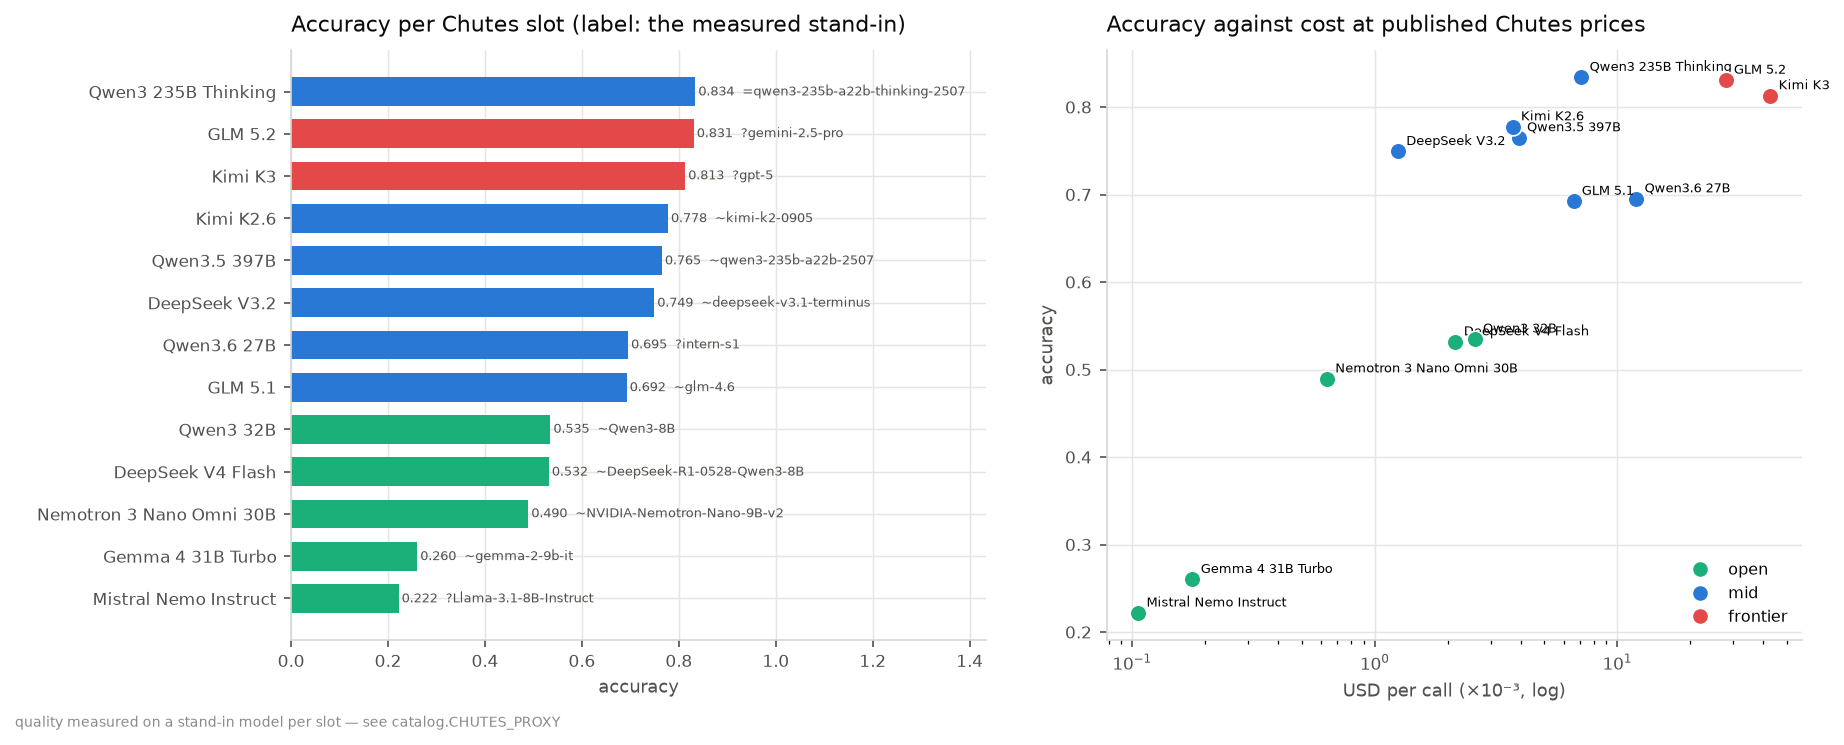

*The thirteen slots: measured accuracy, and cost at published Chutes prices. Labels give the stand-in behind each one.*

In [5]:
show("chutes_01_pool", "The thirteen slots: measured accuracy, and cost at published "
     "Chutes prices. Labels give the stand-in behind each one.")

## The result, against the baseline that can actually win

Two baselines are reported everywhere, and the order matters. The **frontier model** is
what a team does today by wiring everything to the strongest model. The **best single
model** is the one that is already optimal on this pool once price is counted — a much
harder opponent, and on this pool it beats the frontier model on quality *and* price.

In [6]:
cv = load("chutes/11_crossval"); pol = load("chutes/06_policies")
md(f"""
Over {len(cv['seeds'])} random splits at the calibrated dial:

| against | cheaper by | quality kept |
|---|---|---|
| {pol['frontier_model']} (strongest) | **{pct(cv['savings_vs_frontier']['mean'])}** ± {pct(cv['savings_vs_frontier']['se'])} | {pct(cv['quality_vs_frontier']['mean'])} |
| {pol['best_single_model']} (best value) | **{pct(cv['savings_vs_best_single']['mean'])}** ± {pct(cv['savings_vs_best_single']['se'])} | {pct(cv['quality_vs_best_single']['mean'])} |

The second row is the number to quote.
""")


Over 8 random splits at the calibrated dial:

| against | cheaper by | quality kept |
|---|---|---|
| zai-org/GLM-5.2-TEE (strongest) | **79.6%** ± 0.3% | 97.8% |
| Qwen/Qwen3-235B-A22B-Thinking-2507-TEE (best value) | **19.5%** ± 1.4% | 98.6% |

The second row is the number to quote.


In [7]:
display(table([{"policy": p["policy"], "quality": round(p["quality"], 4),
                "$ / call": round(p["cost_per_call_usd"], 6),
                "vs frontier": pct(p["savings_vs_frontier_pct"]),
                "vs best single": pct(p["savings_vs_best_single_pct"])}
               for p in pol["policies"]]))
finding("correction",
        f"{pol['frontier_model']} is the highest-quality model and is beaten outright on "
        f"both axes by {', '.join(pol['models_beating_the_frontier_model'])}. Savings "
        f"quoted against it are inflated by a gap the router had nothing to do with.")

,policy,quality,$ / call,vs frontier,vs best single
0,router,0.8289,0.0057,79.7%,20.1%
1,best-single (utility),0.8341,0.0071,74.6%,0.0%
2,frontier model (GLM 5.2),0.8309,0.0279,0.0%,-293.5%
3,cheapest model,0.4895,0.0006,97.7%,91.1%
4,random,0.6380,0.0100,64.1%,-41.3%
5,"oracle (per item, utility)",0.9726,0.0027,90.2%,61.6%
6,"oracle (per item, quality)",0.9734,0.0039,86.2%,45.6%


> **CORRECTION** — zai-org/GLM-5.2-TEE is the highest-quality model and is beaten outright on both axes by Qwen/Qwen3-235B-A22B-Thinking-2507-TEE. Savings quoted against it are inflated by a gap the router had nothing to do with.

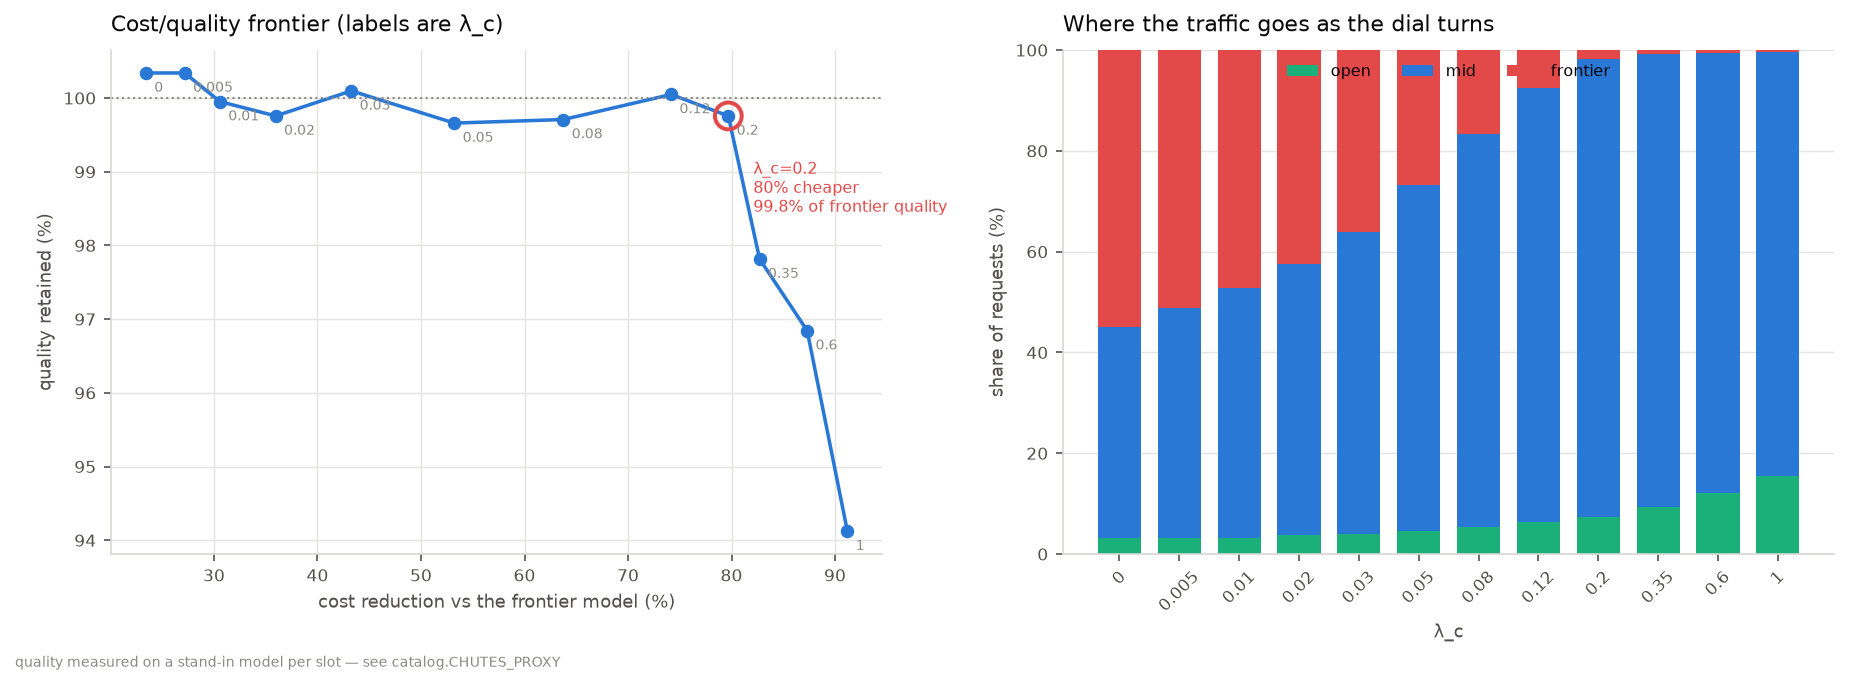

*The dial. Left: what each lambda_c buys. Right: where the traffic goes as it turns.*

In [8]:
show("chutes_02_frontier", "The dial. Left: what each lambda_c buys. Right: where the "
     "traffic goes as it turns.")

## Three things that had to be fixed before any of this was true

### 1. The inherited operating point was wrong by more than the whole result

In [9]:
cal = load("chutes/04_calibration")
at05 = next(g for g in cal["grid"] if abs(g["lam_cost"] - 0.05) < 1e-9)
finding("correction",
        f"lambda_c = 0.05 is this package's calibrated dial on RouterBench. Carried over "
        f"unexamined it spends {abs(at05['savings_vs_best_single']):.0%} MORE than doing "
        f"nothing, for less quality. It weights a cost *ratio*, and this pool's ratios "
        f"span three orders of magnitude where RouterBench's span one. "
        f"Calibrated here: lambda_c = {cal['chosen_lam_cost']}.")
display(table([{"lambda_c": g["lam_cost"], "quality vs best single": pct(g["quality_vs_best_single"]),
                "cheaper by": pct(g["savings_vs_best_single"])} for g in cal["grid"]]))

> **CORRECTION** — lambda_c = 0.05 is this package's calibrated dial on RouterBench. Carried over unexamined it spends 84% MORE than doing nothing, for less quality. It weights a cost *ratio*, and this pool's ratios span three orders of magnitude where RouterBench's span one. Calibrated here: lambda_c = 0.2.

,lambda_c,quality vs best single,cheaper by
0,0.0000,100.0%,-201.3%
1,0.0100,99.6%,-173.2%
2,0.0200,99.4%,-152.0%
3,0.0500,99.3%,-84.1%
4,0.0800,99.3%,-42.6%
5,0.1200,99.7%,-1.6%
6,0.1600,99.3%,10.5%
7,0.2000,99.4%,20.1%
8,0.2500,98.6%,24.5%
9,0.3000,97.8%,28.3%


### 2. Ten times more training data made the router worse

> **NEW FINDING** — dense-core training retains 100.3% of frontier quality on 2,302 items; the union arm has 10x the items and retains 88.1%. Uneven coverage across columns costs more than the extra data buys.

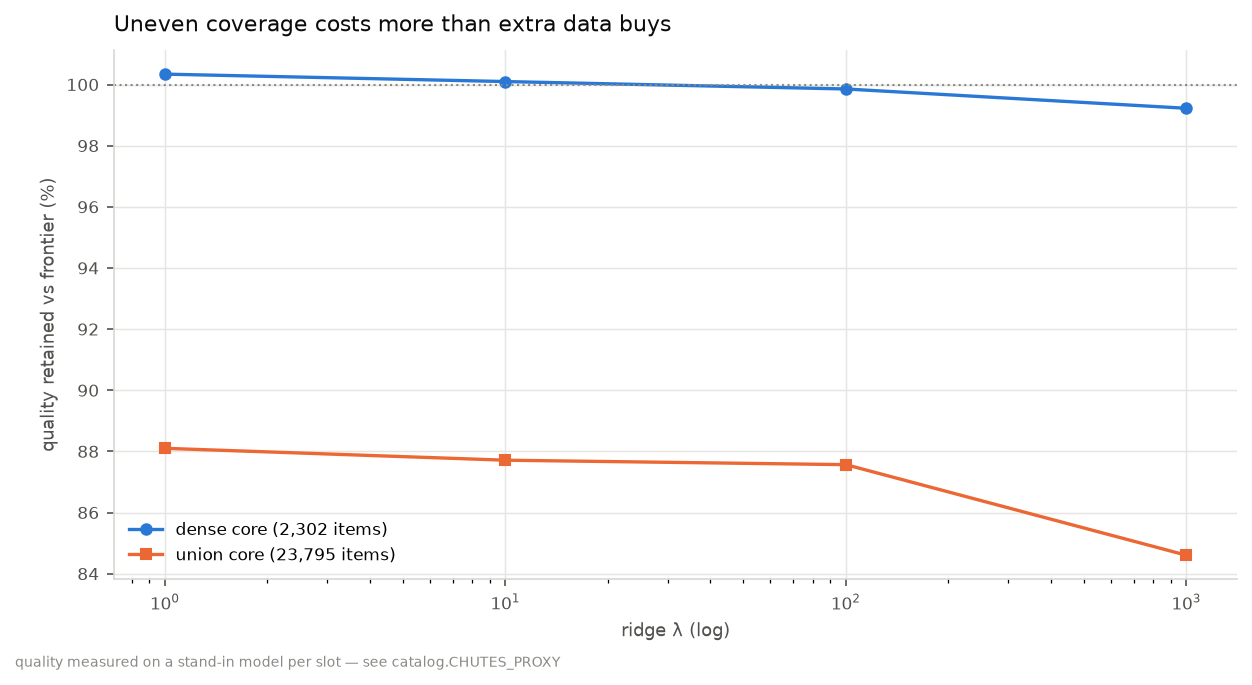

*Same held-out items in both arms; only the training set differs. Uneven coverage across columns costs more than the extra data buys.*

In [10]:
ab = load("chutes/03_ablation")
finding("new", ab["reading"])
show("chutes_05_coverage", "Same held-out items in both arms; only the training set "
     "differs. Uneven coverage across columns costs more than the extra data buys.")

### 3. Four hundred and seventy 'measurements' were failed calls

Zero input tokens, zero output tokens, and a score of exactly 0.0 where every other cell
averages 0.60. Left in, the quality lane learns a reliability failure as an inability to
answer and the cost lane learns the model was free — and on the two items where the
*reference* model failed, c_ref lands in a denominator and mean utility goes to −439,045.
They are marked unobserved. The 31 cells that were billed for input and returned nothing
are real failures and stay.

## How much model, and how much data

No epoch loop here either — the estimator is closed-form. But the two questions that
decide the bill still have answers, and they disagree with each other.

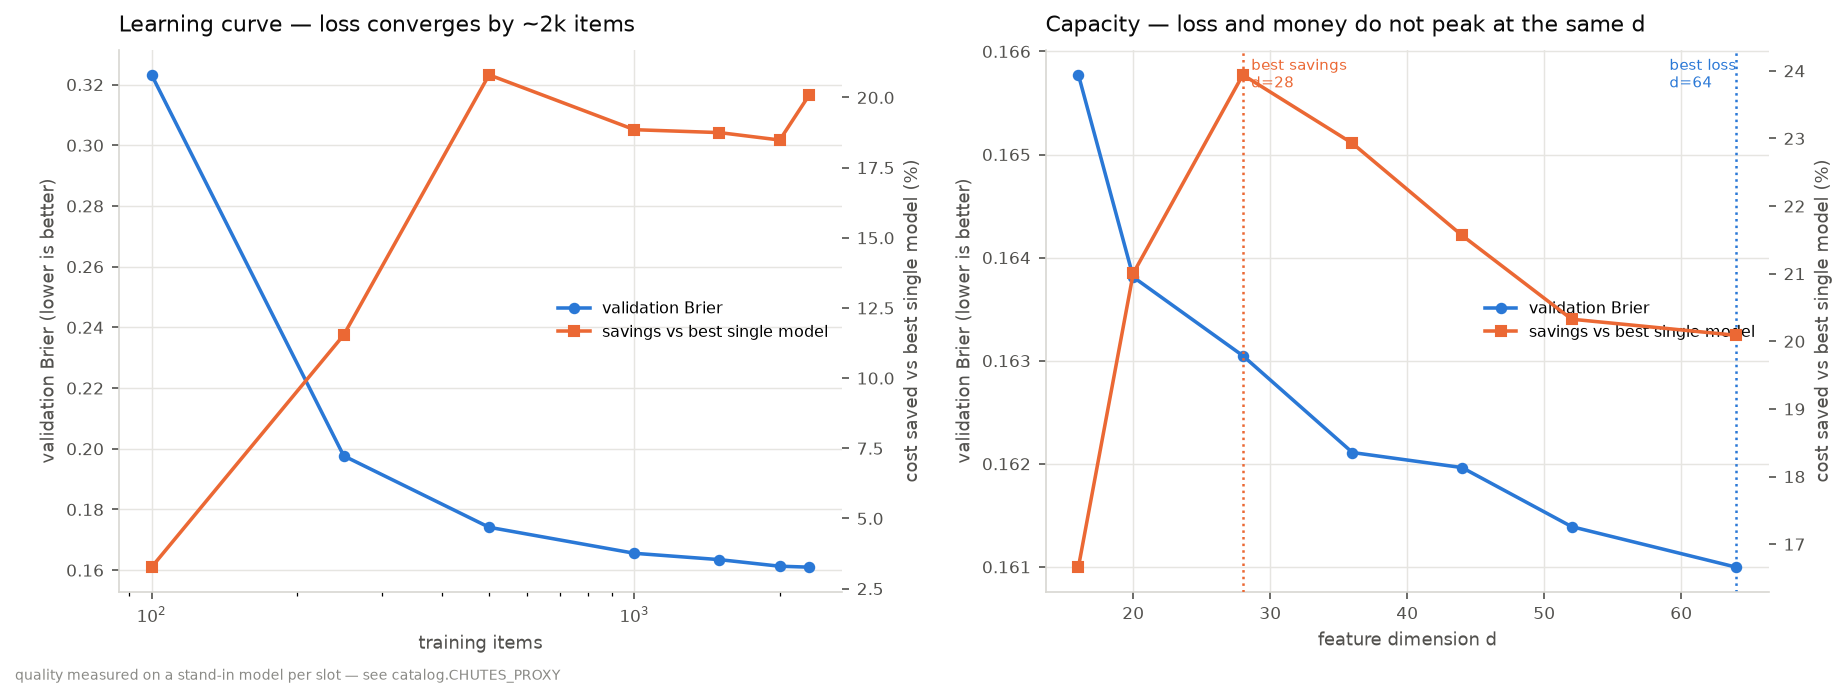

*Loss against data and against capacity, each beside what it buys.*

> **NEW FINDING** — Validation loss is still falling at d = 64 while savings peak at d = 28. Sizing on the loss curve alone ships a five-times-larger artifact that routes slightly worse — the same split notebook 08 found on a different corpus and a different pool.

In [11]:
sc = load("chutes/09_scaling")
show("chutes_06_loss", "Loss against data and against capacity, each beside what it buys.")
finding("new",
        f"Validation loss is still falling at d = {sc['coupling']['best_d_by_loss']} while "
        f"savings peak at d = {sc['coupling']['best_d_by_savings']}. Sizing on the loss "
        f"curve alone ships a five-times-larger artifact that routes slightly worse — the "
        f"same split notebook 08 found on a different corpus and a different pool.")

## Price is read, never fitted

The one claim here a competitor cannot answer by training harder. Price, latency and
availability are read from a live table at decision time, so a price change reaches
routing with no refit and no redeploy. That is testable, so it is tested: the fitted
weights are hashed either side of the change.

In [12]:
pr = load("chutes/10_prices"); sh = pr["shock"]
md(f"Live list read from `llm.chutes.ai/v1/models`: "
   f"**{'in sync' if pr.get('diff', {}).get('in_sync') else 'DRIFTED'}** with the shipped catalogue.")
display(table([{"price": f"{p['factor']}x", "its traffic share": pct(p["target_share_after"]),
                "bill, reacting": round(p["spend_after_usd"], 2),
                "bill, frozen": round(p["spend_if_frozen_usd"], 2),
                "saved": round(p["saved_by_reacting_usd"], 2)} for p in sh["points"]]))
finding("supported", sh["reading"])

Live list read from `llm.chutes.ai/v1/models`: **in sync** with the shipped catalogue.

,price,its traffic share,"bill, reacting","bill, frozen",saved
0,0.25x,60.5%,3.0700,3.5900,0.5300
1,0.5x,54.4%,4.6700,4.7400,0.0700
2,0.75x,47.9%,6.0200,5.8800,-0.1400
3,1.0x,42.6%,7.0200,7.0200,0.0000
4,1.5x,31.1%,8.5900,9.3100,0.7200
5,2.0x,22.4%,9.2400,11.6000,2.3600
6,4.0x,3.3%,7.6100,20.7500,13.1400


> **SUPPORTED** — Halving Qwen3 235B Thinking's price moves its traffic share from 42.6% to 54.4%; doubling it moves it to 22.4%. No refit — the fitted state is unchanged at every point.

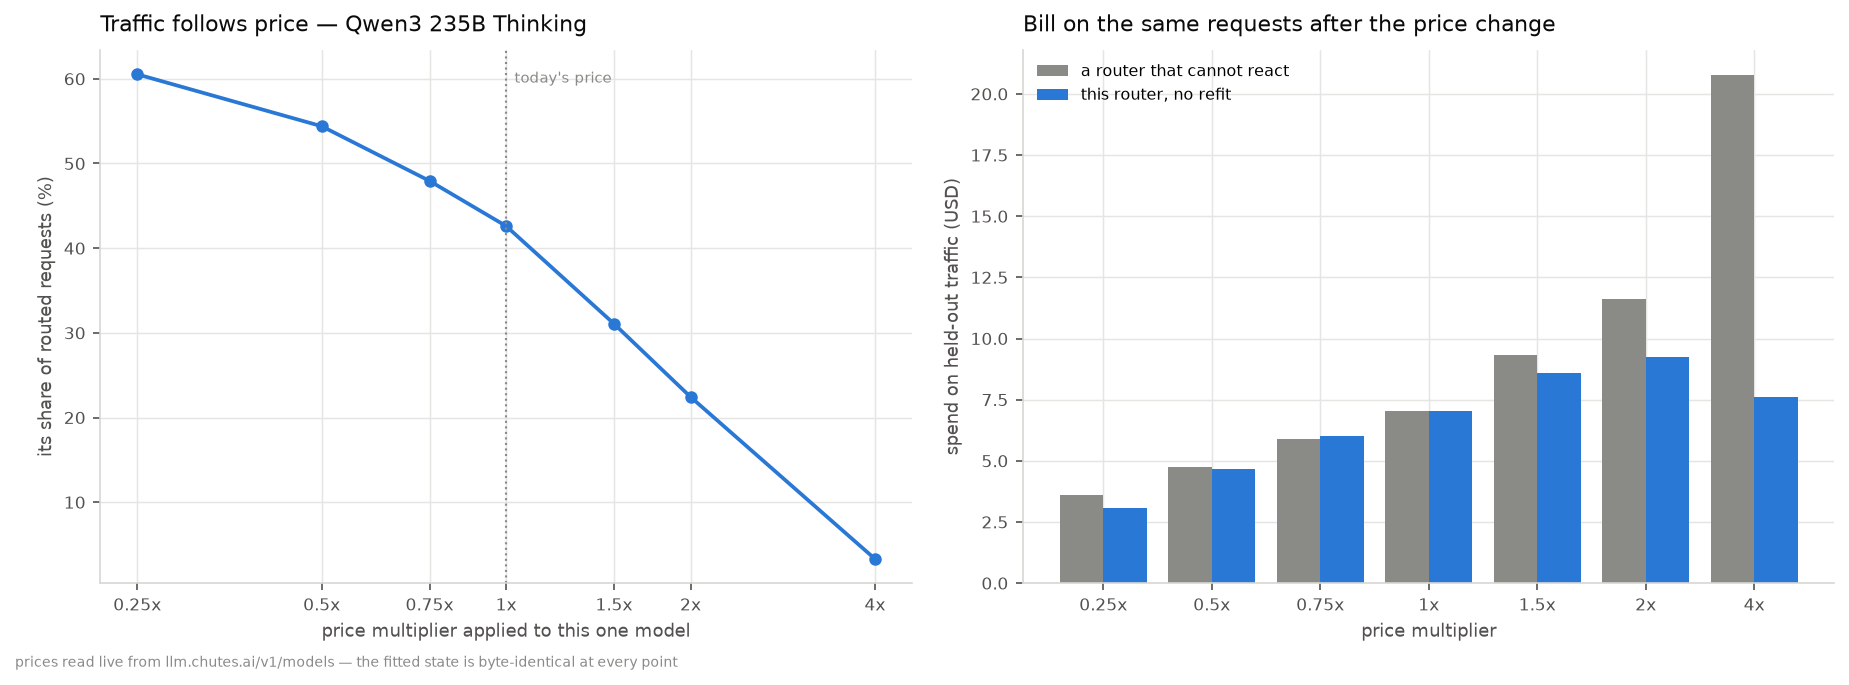

*Traffic follows price, and the bill follows with it — with the trained model byte-identical at every point.*

In [13]:
show("chutes_07_prices", "Traffic follows price, and the bill follows with it — with the "
     "trained model byte-identical at every point.")

## Where the headroom is

In [14]:
an = load("chutes/07_analytics")
sav = load("chutes/06_policies")
r = next(p for p in sav["policies"] if p["policy"] == "router")
o = next(p for p in sav["policies"] if p["policy"] == "oracle (per item, quality)")
md(f"""
The router scores **{r['quality']:.3f}**. A per-item oracle scores **{o['quality']:.3f}**.
So the decision rule is capturing {r['quality'] / o['quality']:.1%} of what perfect
per-question knowledge would get — the ceiling here is the quality prediction
(Brier skill {an['prediction_quality']['brier_skill_score']:+.3f}, pairwise ranking
concordance {an['prediction_quality']['pairwise_ranking_concordance']:.3f}), not the argmax.

Two of thirteen slots never win a request: {', '.join(an['unused_models'])}.
""")
display(table(an["domains"], ["domain", "items", "best_quality_model", "router_quality",
                              "oracle_quality", "router_top_model"]))


The router scores **0.829**. A per-item oracle scores **0.973**.
So the decision rule is capturing 85.2% of what perfect
per-question knowledge would get — the ceiling here is the quality prediction
(Brier skill +0.257, pairwise ranking
concordance 0.826), not the argmax.

Two of thirteen slots never win a request: Mistral Nemo Instruct, Gemma 4 31B Turbo.


,domain,items,best_quality_model,router_quality,oracle_quality,router_top_model
0,code,395,moonshotai/Kimi-K3-TEE,0.8532,0.9785,Qwen/Qwen3-235B-A22B-Thinking-2507-TEE
1,knowledge,343,zai-org/GLM-5.2-TEE,0.8017,0.9504,deepseek-ai/DeepSeek-V3.2-TEE
2,math,117,Qwen/Qwen3-235B-A22B-Thinking-2507-TEE,0.8077,0.9701,Qwen/Qwen3-235B-A22B-Thinking-2507-TEE
3,openended,326,Qwen/Qwen3-235B-A22B-Thinking-2507-TEE,0.8543,0.9877,Qwen/Qwen3-235B-A22B-Thinking-2507-TEE
4,science,58,moonshotai/Kimi-K3-TEE,0.7241,1.0000,Qwen/Qwen3-235B-A22B-Thinking-2507-TEE


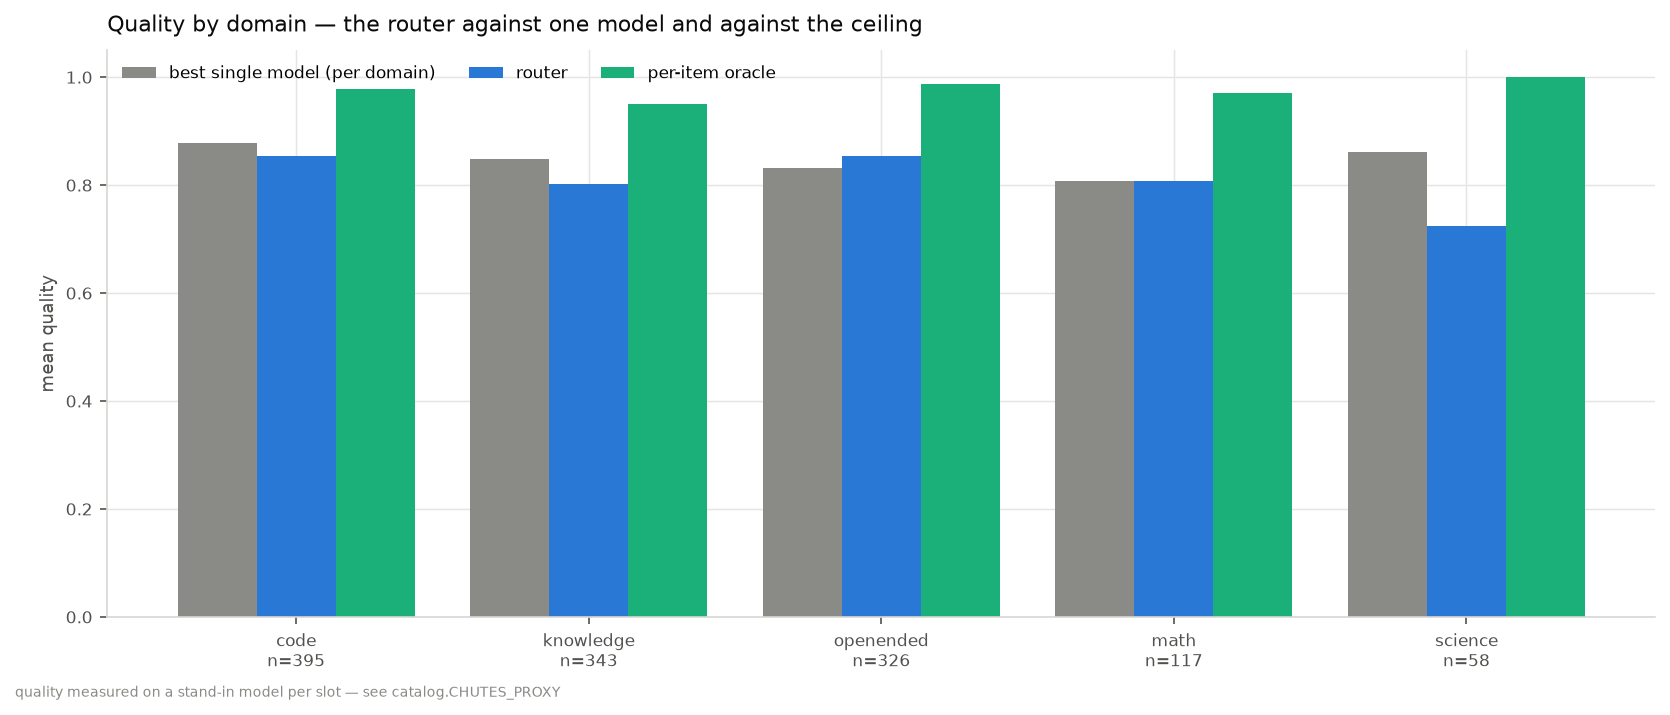

*Router against the best single model per domain, and against the per-item ceiling.*

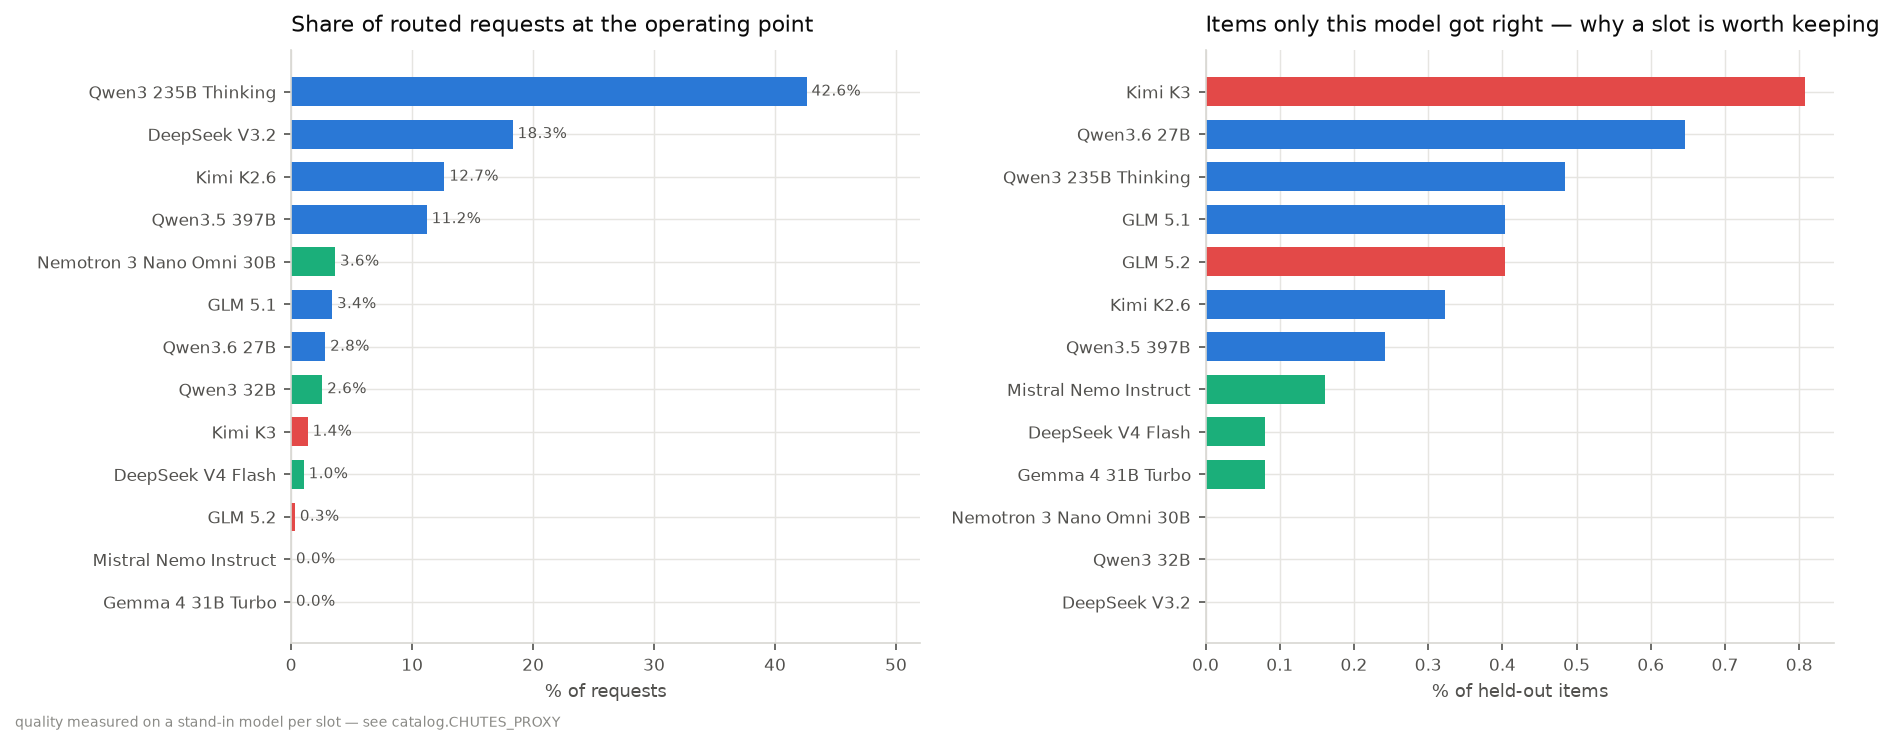

*Who gets the requests, and which slots earn theirs.*

In [15]:
show("chutes_04_domains", "Router against the best single model per domain, and against "
     "the per-item ceiling.")
show("chutes_03_traffic", "Who gets the requests, and which slots earn theirs.")

## The two slots that never win

They take 0% of traffic at every dial setting. The first instinct is to retire them. The
measurement says the opposite.

,model,oracle would send,router sends
0,Mistral-Nemo-Instruct-2407-TEE,22.2%,0.0%
1,Nemotron-3-Nano-Omni-30B-TEE,21.8%,3.6%
2,DeepSeek-V3.2-TEE,20.5%,18.3%
3,gemma-4-31B-turbo-TEE,8.6%,0.0%
4,Kimi-K2.6-TEE,6.5%,12.7%
5,DeepSeek-V4-Flash-0731-TEE,5.0%,1.0%
6,Qwen3-235B-A22B-Thinking-2507-TEE,3.9%,42.6%
7,Qwen3-32B-TEE,3.8%,2.6%
8,Qwen3.5-397B-A17B-TEE,3.0%,11.2%
9,GLM-5.1-TEE,2.4%,3.4%


> **NEW FINDING** — The router sends unsloth/Mistral-Nemo-Instruct-2407-TEE, google/gemma-4-31B-turbo-TEE no traffic at all, but a per-item oracle sends them 30.8%. They are not dominated — they are unreachable. At ≥98% of Qwen/Qwen3-235B-A22B-Thinking-2507-TEE's quality the threshold rule (τ=0.85) is -78.7% cheaper against the argmax's 20.1%, and it puts 7% of traffic on the open tier against 7%.

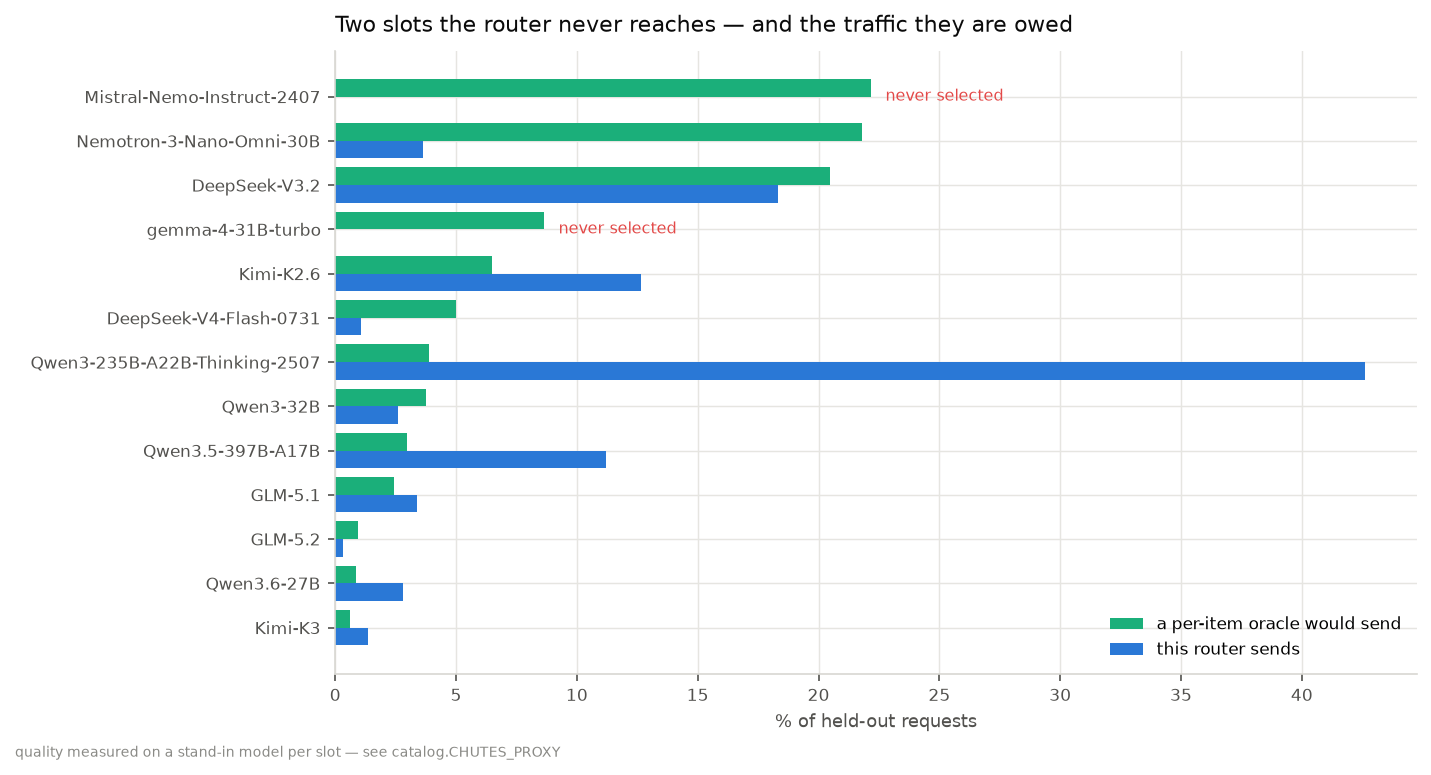

*Green: what a per-item oracle would send each slot. Blue: what the router sends. The gap on the top row is the largest unclaimed value in the pool.*

In [16]:
sl = load("chutes/12_slots")
orc, rtr = sl["oracle_share"], sl["router_share"]
display(table([{"model": k.split("/")[-1], "oracle would send": pct(orc[k]),
                "router sends": pct(rtr.get(k, 0.0))}
               for k in sorted(orc, key=lambda x: -orc[x])]))
finding("new", sl["reading"])
show("chutes_09_slots", "Green: what a per-item oracle would send each slot. Blue: what "
     "the router sends. The gap on the top row is the largest unclaimed value in the pool.")

The reason is arithmetic, not preference. Mistral Nemo's predicted quality averages 0.215
with a per-item spread of 0.160; Qwen3 235B Thinking averages 0.830 with a spread of 0.078.
Under an argmax the cheap model needs a four-sigma excursion to win, so it never does.

The rule the product advertises — *cheapest model that will get this right* — is a
threshold, not an argmax, and a threshold **can** pick a cheap model whenever it is good
enough. So it was implemented and swept. It loses.

In [17]:
th = sl["threshold_rule"]
rows = [{"rule": "argmax (current)", "quality vs best single": pct(th["argmax"]["quality_vs_best_single"]),
         "cheaper by": pct(th["argmax"]["savings_vs_best_single"]),
         "open-tier share": pct(th["argmax"]["open_tier_share"])}]
rows += [{"rule": f"threshold tau={g['tau']:g}", "quality vs best single": pct(g["quality_vs_best_single"]),
          "cheaper by": pct(g["savings_vs_best_single"]),
          "open-tier share": pct(g["open_tier_share"])} for g in th["grid"]]
display(table(rows))
finding("not-supported",
        "An argmax needs only the ORDER between models to be right; a threshold needs the "
        "LEVEL. The level is the badly-estimated half (Brier skill +0.257), so the simpler "
        "rule wins. Keep both slots, and fix the estimator rather than the decision rule.")

,rule,quality vs best single,cheaper by,open-tier share
0,argmax (current),99.4%,20.1%,7.3%
1,threshold tau=0.3,59.9%,84.7%,73.8%
2,threshold tau=0.4,72.8%,81.0%,58.3%
3,threshold tau=0.5,80.5%,78.0%,42.0%
4,threshold tau=0.55,84.3%,76.2%,34.1%
5,threshold tau=0.6,87.4%,73.9%,26.5%
6,threshold tau=0.65,89.7%,69.6%,19.8%
7,threshold tau=0.7,93.3%,57.8%,15.5%
8,threshold tau=0.75,95.7%,31.7%,11.5%
9,threshold tau=0.8,97.7%,-7.2%,8.3%


> **NOT SUPPORTED** — An argmax needs only the ORDER between models to be right; a threshold needs the LEVEL. The level is the badly-estimated half (Brier skill +0.257), so the simpler rule wins. Keep both slots, and fix the estimator rather than the decision rule.

## Does this pool go stale too?

Notebook 03 measured decay on 2023 commercial models. Repeating it here is the closest
thing to an independent replication: different models, different generation, different
corpus, same question. Release dates are attached by hand from the labs' announcements —
the one hand-entered input in this half of the package.

,,RouterBench (2023),Chutes pool (current)
0,"frozen, start -> end",+0.010 -> -1.012,+0.127 -> -1.062
1,"rolling, start -> end",-0.003 -> -0.023,+0.151 -> -0.148
2,crosses below best single,week 5,week 9
3,share of gap from NEW MODELS,98.7%,93.3%


> **SUPPORTED** — The decay replicates on the current pool, and so does its cause. Fresh data on models you already have is worth almost nothing; access to models that just shipped is worth almost everything.

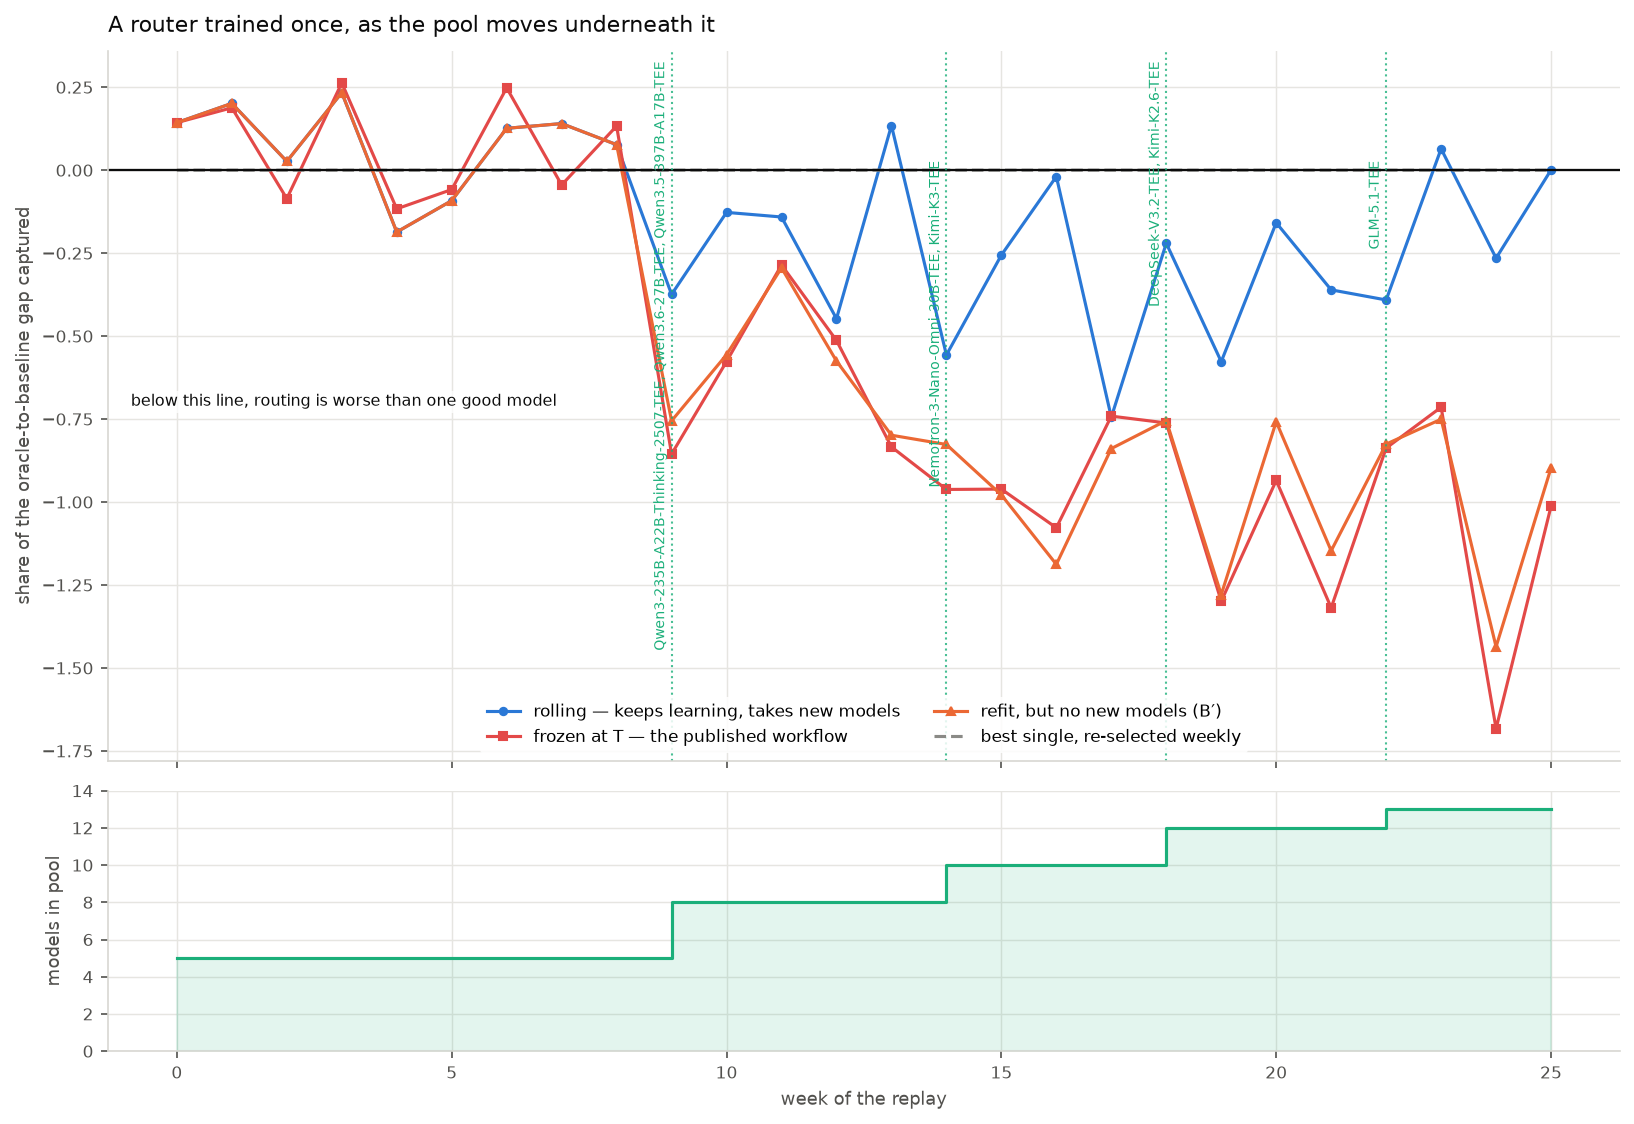

*The same four-arm replay on the models the product serves.*

In [18]:
cst = load("chutes/13_staleness")["summary"]
rb = load("staleness")["summary"]
share = lambda s: abs(s["attribution_new_models"]) / (abs(s["attribution_new_models"]) + abs(s["attribution_fresher_data"]))
display(table([
    {"": "frozen, start -> end", "RouterBench (2023)": f"{rb['frozen_start']:+.3f} -> {rb['frozen_end']:+.3f}",
     "Chutes pool (current)": f"{cst['frozen_start']:+.3f} -> {cst['frozen_end']:+.3f}"},
    {"": "rolling, start -> end", "RouterBench (2023)": f"{rb['rolling_start']:+.3f} -> {rb['rolling_end']:+.3f}",
     "Chutes pool (current)": f"{cst['rolling_start']:+.3f} -> {cst['rolling_end']:+.3f}"},
    {"": "crosses below best single", "RouterBench (2023)": f"week {rb['week_crossed_below_best_single']}",
     "Chutes pool (current)": f"week {cst['week_crossed_below_best_single']}"},
    {"": "share of gap from NEW MODELS", "RouterBench (2023)": pct(share(rb)),
     "Chutes pool (current)": pct(share(cst))},
]))
finding("supported",
        "The decay replicates on the current pool, and so does its cause. Fresh data on "
        "models you already have is worth almost nothing; access to models that just "
        "shipped is worth almost everything.")
show("chutes_08_staleness", "The same four-arm replay on the models the product serves.")

### And onboarding a new model has a price

In [19]:
cs = load("chutes/14_coldstart")["summary"]
md(f"""
{len(cs['material_models'])} of 13 slots have a material gap when introduced cold. For
those, probe items needed before the router can use them:

{chr(10).join(f'- **{k}** — {v}' for k, v in cs['median_probe_items_material'].items())}

So a newly-shipped model costs roughly **1,000 graded questions** before it is selectable,
and only the informative prior gets there at all. That is what makes the 93% above
expensive to capture rather than free — and it is also the moat: an incumbent onboards in a
day, a newcomer needs 1,000 questions per model before its router is even correct.
""")


4 of 13 slots have a material gap when introduced cold. For
those, probe items needed before the router can use them:

- **blend (§8.6)** — 1000.0
- **derived (§5.2)** — None
- **no prior** — None

So a newly-shipped model costs roughly **1,000 graded questions** before it is selectable,
and only the informative prior gets there at all. That is what makes the 93% above
expensive to capture rather than free — and it is also the moat: an incumbent onboards in a
day, a newcomer needs 1,000 questions per model before its router is even correct.


## Latency — what the corpus supports, and what it does not

The corpus publishes wall-clock per *run*, never per record. The obvious move is to fit
throughput per model and divide. That was implemented, and then checked.

In [20]:
lat = load("chutes/15_latency")
tf = lat["throughput_fit"]
md(f"Fitted throughputs: median **{tf['median_tok_s']:,.0f} tok/s**, max "
   f"**{tf['max_tok_s']:,.0f} tok/s** across {tf['models_fitted']} models.")
finding("not-supported", tf["verdict"])

Fitted throughputs: median **1,067 tok/s**, max **10,810 tok/s** across 38 models.

> **NOT SUPPORTED** — NOT USABLE as per-request latency: 26 of 38 models fit above 500 tok/s (max 10810) and 22 of 38 fits have R² < 0.3. The runs were concurrent, so wall-clock measures harness throughput, not request latency. Routing uses measured output tokens instead.

So latency is routed on **measured output tokens** — exactly measured, rather than
seconds roughly invented. Within a model, that is what decides how long a request takes.

,lambda_l,quality,p50 tokens,p95 tokens,p99 tokens,cheaper vs frontier
0,0.0000,0.8289,"1,752","18,195","28,857",79.7%
1,0.0200,0.8245,"1,374","18,025","28,023",80.2%
2,0.0500,0.8184,991,"15,746","26,467",81.1%
3,0.1000,0.7885,740,"8,671","22,633",83.9%
4,0.2000,0.7760,639,"3,282","7,857",88.1%
5,0.4000,0.7688,624,"2,976","5,302",91.5%
6,0.8000,0.7607,611,"2,903","4,833",93.5%


> **NEW FINDING** — Turning the latency term on at lambda_l=0.1 cuts routed p95 by 52% AND raises savings from 79.7% to 83.9%, for -0.0404 of quality. A shorter answer is both faster and cheaper, so the two objectives point the same way — which nothing in the source documents anticipates.

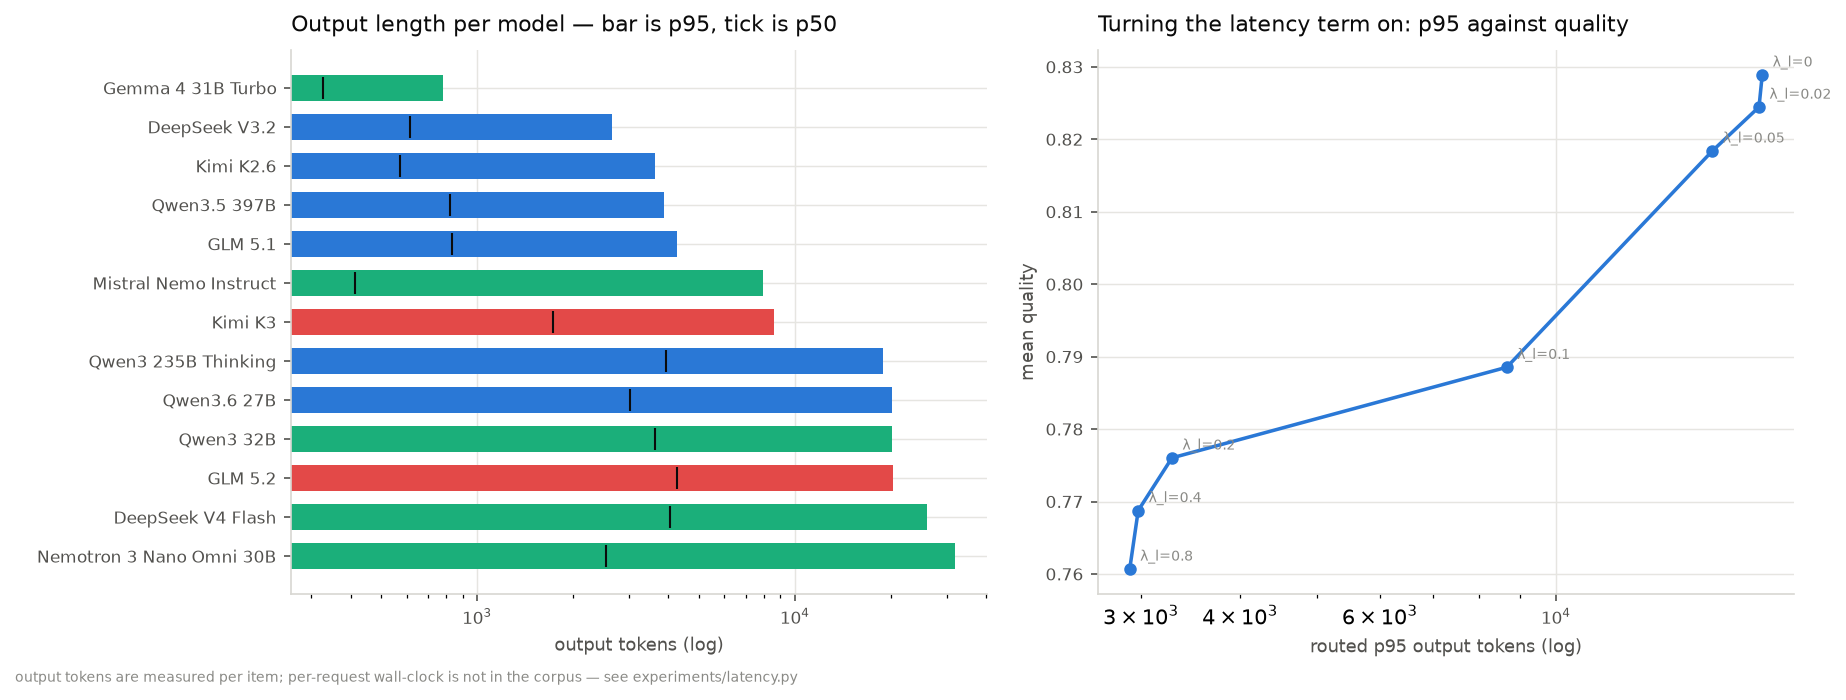

*Left: output length per slot, bar is p95 and tick is p50. Right: the latency term switched on for the first time.*

In [21]:
display(table([{"lambda_l": s["lam_latency"], "quality": round(s["quality"], 4),
                "p50 tokens": f"{s['p50_tokens']:,.0f}", "p95 tokens": f"{s['p95_tokens']:,.0f}",
                "p99 tokens": f"{s['p99_tokens']:,.0f}",
                "cheaper vs frontier": pct(s["savings_vs_frontier"])}
               for s in lat["lam_latency_sweep"]]))
off = lat["lam_latency_sweep"][0]
at = min(lat["lam_latency_sweep"], key=lambda s: abs(s["lam_latency"] - 0.1))
finding("new",
        f"Turning the latency term on at lambda_l=0.1 cuts routed p95 by "
        f"{1 - at['p95_tokens'] / off['p95_tokens']:.0%} AND raises savings from "
        f"{off['savings_vs_frontier']:.1%} to {at['savings_vs_frontier']:.1%}, for "
        f"{at['quality'] - off['quality']:+.4f} of quality. A shorter answer is both "
        f"faster and cheaper, so the two objectives point the same way — which nothing in "
        f"the source documents anticipates.")
show("chutes_10_latency", "Left: output length per slot, bar is p95 and tick is p50. "
     "Right: the latency term switched on for the first time.")

## What this notebook does not show

- **The release dates are hand-entered** from public announcements, at month resolution.
  They can move *when* a model joins the replay; they cannot change any model's quality or
  price. RouterBench's dates are the ones that need no such caveat, which is why its 2023
  models are still in this repository.
- **No per-request latency exists anywhere in the corpus.** Seconds appear only at a stated
  assumed decode rate, and queueing is invisible to all of it.
- **3,541 items, nine benchmarks**, all of them hard — AIME, GPQA, LiveCodeBench, MMLU-Pro,
  Arena-Hard. RouterBench's 36,497 are mostly multiple-choice, so difficulty and headroom
  are not comparable between the two halves of this repo.
- **The bindings are the result.** Change one and the numbers move. The dominant-model
  finding in particular is a joint property of measured stand-in quality and real Chutes
  prices.